## Employee Open-Ended Survey Response Analysis 

In [14]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import pipeline
from scipy.stats import chi2_contingency
import re
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

### Import data 

In [2]:
file_path = '/Users/nicole.burke/Downloads/employee_sentiment_analysis/employee_survey_data.csv'
df = pd.read_csv(file_path)

# Look at data 
print(df.head())

  employee_id job_level   department start_date survey_date  tenure_years  \
0     EMP0001       IC1      Product    4/18/23     11/1/24           1.5   
1     EMP0002       IC2        Legal    1/12/21     11/1/24           3.8   
2     EMP0003       IC1    Marketing     9/9/21     11/1/24           3.1   
3     EMP0004        M3    Marketing    1/31/18     11/1/24           6.8   
4     EMP0005       IC5  People & HR   12/29/21     11/1/24           2.8   

                                             comment _ground_truth_sentiment  \
0  My manager is a genuine advocate for my develo...                positive   
1  My manager is fine and my comp is competitive,...                 neutral   
2  Leadership has been transparent about the chal...                positive   
3  We have strong rituals for alignment and rarel...                positive   
4  This is the most inclusive team I've been on. ...                positive   

                           _ground_truth_theme  
0     m

In [3]:
## Data Overview 
print("Shape of dataframe:", df.shape)
print("-"*40)
print(df.info())
print("-"*40)
print(str(df.dtypes))
print("-"*40)
print(f"Unique employee IDs: {df['employee_id'].nunique()}")

Shape of dataframe: (300, 9)
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   employee_id              300 non-null    object 
 1   job_level                300 non-null    object 
 2   department               300 non-null    object 
 3   start_date               300 non-null    object 
 4   survey_date              300 non-null    object 
 5   tenure_years             300 non-null    float64
 6   comment                  300 non-null    object 
 7   _ground_truth_sentiment  300 non-null    object 
 8   _ground_truth_theme      300 non-null    object 
dtypes: float64(1), object(8)
memory usage: 21.2+ KB
None
----------------------------------------
employee_id                 object
job_level                   object
department                  object
start_date                  

In [4]:
### Make sure date columns are read as dates
df['start_date'] = pd.to_datetime(df['start_date'])
df['survey_date'] = pd.to_datetime(df['survey_date'])

# Check 
print(str(df.dtypes))

employee_id                        object
job_level                          object
department                         object
start_date                 datetime64[ns]
survey_date                datetime64[ns]
tenure_years                      float64
comment                            object
_ground_truth_sentiment            object
_ground_truth_theme                object
dtype: object


/var/folders/xq/f83j3jh14fz6j650prgjddldpxs0f4/T/ipykernel_3018/2660392360.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['start_date'] = pd.to_datetime(df['start_date'])


### Sentiment Analysis

In [5]:
# Sentiment analysis pipeline
classifier = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment-latest")

# Filter out dataferame for missing comments
df_with_comments = df[df['comment'].notna()].copy()
print("Shape of df_with_comments:", df_with_comments.shape)

# Function to classify sentiment and return both label and score
def classify_sentiment(text):
    if pd.isna(text) or text == '':
        return pd.Series({'sentiment': 'neutral', 'sentiment_score': 0.0})
    
    try:
        # Get prediction
        result = classifier(text[:512])[0]  # Truncate to 512 chars for model limit
        label = result['label']
        score = result['score']
        
        # Map labels to positive/neutral/negative
        if label == 'positive':
            sentiment = 'positive'
        elif label == 'negative':
            sentiment = 'negative'
        else:
            sentiment = 'neutral'
            
        return pd.Series({'sentiment': sentiment, 'sentiment_score': score})
    except:
        return pd.Series({'sentiment': 'neutral', 'sentiment_score': 0.0})

# Apply classification (returns both sentiment and score)
sentiment_results = df_with_comments['comment'].apply(classify_sentiment)
df_with_comments['sentiment_from_model'] = sentiment_results['sentiment']
df_with_comments['sentiment_score'] = sentiment_results['sentiment_score']

print(df_with_comments.head())

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 39266.66it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Shape of df_with_comments: (300, 9)
  employee_id job_level   department start_date survey_date  tenure_years  \
0     EMP0001       IC1      Product 2023-04-18  2024-11-01           1.5   
1     EMP0002       IC2        Legal 2021-01-12  2024-11-01           3.8   
2     EMP0003       IC1    Marketing 2021-09-09  2024-11-01           3.1   
3     EMP0004        M3    Marketing 2018-01-31  2024-11-01           6.8   
4     EMP0005       IC5  People & HR 2021-12-29  2024-11-01           2.8   

                                             comment _ground_truth_sentiment  \
0  My manager is a genuine advocate for my develo...                positive   
1  My manager is fine and my comp is competitive,...                 neutral   
2  Leadership has been transparent about the chal...                positive   
3  We have strong rituals for alignment and rarel...                positive   
4  This is the most inclusive team I've been on. ...                positive   

                    

### Compare model outputs to ground truth

In [ ]:
### Filter dataframe by sentiment score 
#   filtering >= 0.75 left us with 49% of data
#   filter by >= 0.7 left us with 61% of data
#   filter by >= 0.65 left us with 65% of data
#   choosing 0.7, The question will detrimine what is appropiate cutoff  
df_filtered = df_with_comments[df_with_comments['sentiment_score'] >= 0.7]

print("nrow full dataset:", len(df_with_comments))
print("nrow filtered dataset:", len(df_filtered))

nrow full dataset: 300
nrow filtered dataset: 183


Accuracy: 0.793

Classification Report:
              precision    recall  f1-score   support

    positive       0.91      0.77      0.84       119
     neutral       0.50      0.73      0.59        62
    negative       0.93      0.85      0.89       119

    accuracy                           0.79       300
   macro avg       0.78      0.78      0.77       300
weighted avg       0.83      0.79      0.81       300


Confusion Matrix:
                 Predicted_positive  Predicted_neutral  Predicted_negative
Actual_positive                  92                 27                   0
Actual_neutral                    9                 45                   8
Actual_negative                   0                 18                 101


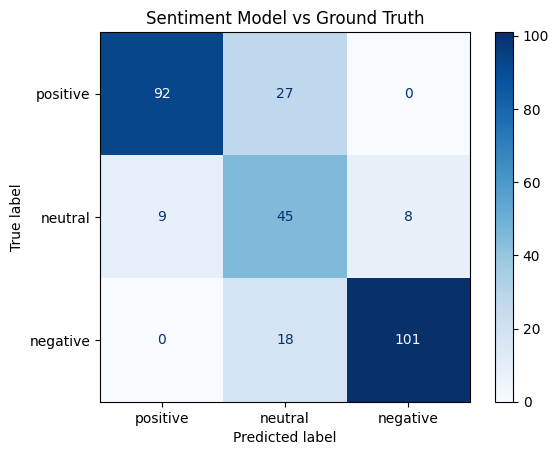


Number of mismatches: 62
   _ground_truth_sentiment sentiment_from_model
1                  neutral             negative
3                 positive              neutral
8                 positive              neutral
11                positive              neutral
17                negative              neutral


In [15]:
# Columns
y_true = df_with_comments["_ground_truth_sentiment"]
y_pred = df_with_comments["sentiment_from_model"]

# Labels
labels = ["positive", "neutral", "negative"]

# Overall accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy:.3f}")

# Detailed metrics
print("\nClassification Report:")
print(classification_report(y_true, y_pred, labels=labels))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

# Convert to dataframe for easier reading
cm_df = pd.DataFrame(
    cm,
    index=[f"Actual_{l}" for l in labels],
    columns=[f"Predicted_{l}" for l in labels]
)

print("\nConfusion Matrix:")
print(cm_df)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.title("Sentiment Model vs Ground Truth")
plt.show()

# Optional: inspect mismatches
mismatches = df_with_comments[
    y_true != y_pred
][[
    "_ground_truth_sentiment",
    "sentiment_from_model"
]]

print(f"\nNumber of mismatches: {len(mismatches)}")
print(mismatches.head())